# Week 3 Assignment: Unsupervised Learning on Country Data

## Objective

HELP International aims to identify countries that require financial assistance based on socio-economic and health indicators.

In this project, unsupervised learning techniques are used to group countries with similar characteristics and identify the most vulnerable countries that may benefit from humanitarian support.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.cluster import AgglomerativeClustering

from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.ensemble import RandomForestClassifier

plt.style.use("default")

## Loading the Dataset

The dataset contains information about 167 countries and several socio-economic indicators such as income, child mortality, life expectancy, GDP per capita, and more.

These indicators will be used to identify patterns and group countries with similar characteristics.

In [2]:
df = pd.read_csv("Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## Data Quality Assessment

Before applying any machine learning algorithm, it is important to check for:

- Missing values
- Duplicate records
- Incorrect data types

This ensures that the dataset is reliable and suitable for analysis.

In [5]:
df.isnull().sum()



,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
df.duplicated().sum()

0

## Exploratory Data Analysis (EDA)

EDA helps in understanding the distribution of features, identifying outliers, and discovering relationships among variables.

The following visualizations will be used:

- Histograms
- Boxplots
- Correlation Heatmap

In [7]:
# Preserve country names for later analysis

country_names = df["country"]

# Features used for analysis and clustering

X = df.drop(columns=["country"])

print(f"Feature matrix shape: {X.shape}")

X.head()

Feature matrix shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [8]:
numerical_cols = X.columns

numerical_cols

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

## Distribution plots

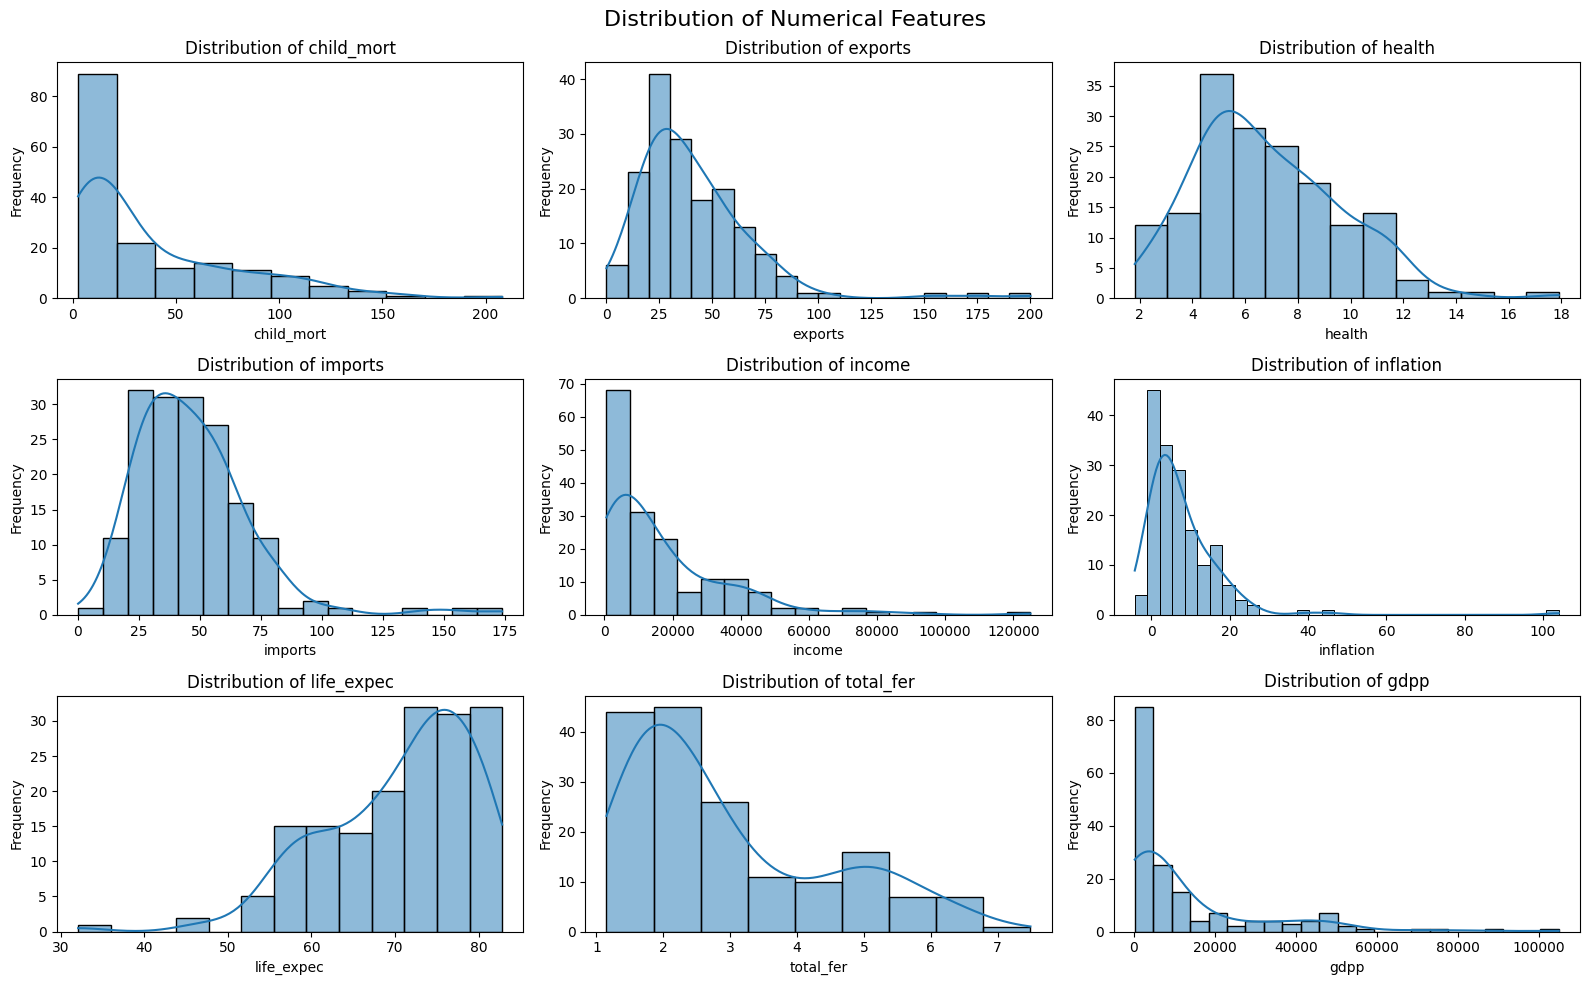

In [9]:
# Distribution plots in a 3x3 grid

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()

plt.show()

### Observation

The distributions show that several variables such as income, GDP per capita, and child mortality are highly skewed. This indicates significant differences among countries and suggests that scaling will be necessary before clustering.

## Boxplots for outlier detection

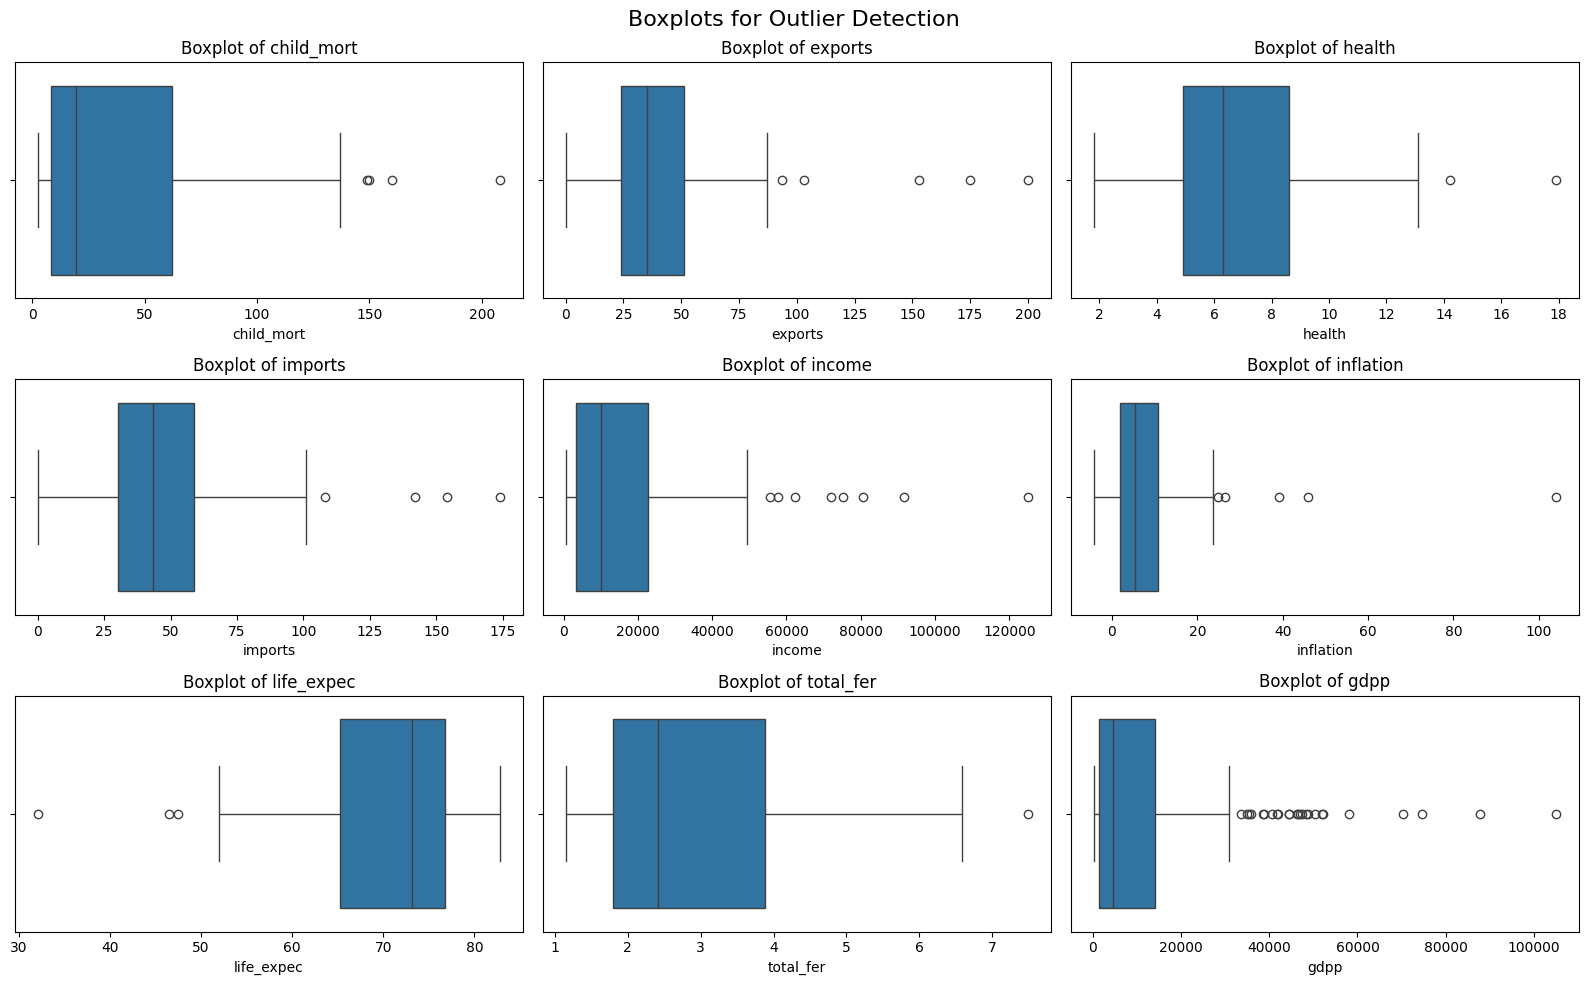

In [10]:
# Boxplots in a 3x3 grid

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    sns.boxplot(
        x=df[column],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {column}")
    axes[i].set_xlabel(column)

plt.suptitle(
    "Boxplots for Outlier Detection",
    fontsize=16
)

plt.tight_layout()

plt.show()

### Observation

A number of variables contain extreme values, particularly GDP, income, and child mortality. These outliers represent genuine country-level differences and will be retained for analysis.

## Correlation matrix

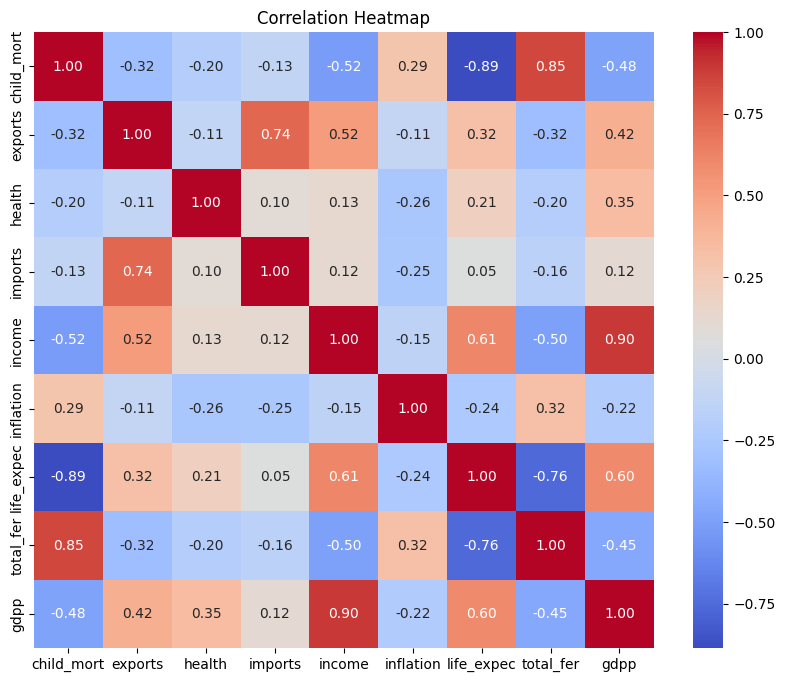

In [11]:
plt.figure(figsize=(10,8))

corr_matrix = X.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Key Insights

- Income and GDP per capita show a strong positive correlation.
- Child mortality has a strong negative relationship with life expectancy.
- Fertility rate tends to increase in countries with lower income levels.
- Health expenditure is positively associated with life expectancy.

These relationships indicate that the variables are suitable for identifying meaningful country clusters.

## Feature Scaling

Clustering algorithms are distance-based methods. Features measured on larger scales can dominate the clustering process.

To ensure equal contribution from all variables, StandardScaler is applied.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [13]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


## Principal Component Analysis (PCA)

The dataset contains several correlated socio-economic indicators. PCA helps reduce dimensionality while preserving most of the information present in the original features.

This also makes cluster visualization easier and improves computational efficiency.

In [14]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [15]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([0.4595174 , 0.17181626, 0.13004259, 0.11053162, 0.07340211,
       0.02484235, 0.0126043 , 0.00981282, 0.00743056])

In [16]:
variance_df = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance": explained_variance,
    "Cumulative Variance": np.cumsum(explained_variance)
})

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.459517,0.459517
1,PC2,0.171816,0.631334
2,PC3,0.130043,0.761376
3,PC4,0.110532,0.871908
4,PC5,0.073402,0.945310
5,PC6,0.024842,0.970152
6,PC7,0.012604,0.982757
7,PC8,0.009813,0.992569
8,PC9,0.007431,1.000000


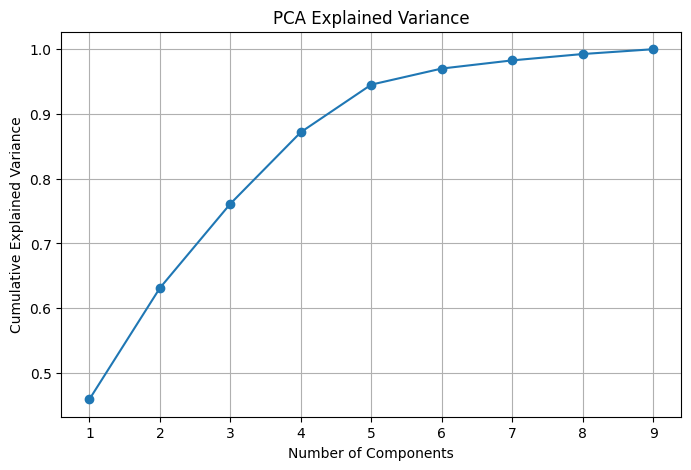

In [17]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

### Observation

The cumulative variance plot helps determine the number of principal components required to retain most of the information present in the dataset.

A threshold of approximately 90% variance is commonly used.

In [18]:
pca = PCA(
    n_components=3,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3"]
)

pca_df.head()

,PC1,PC2,PC3
0,-2.913025,0.095621,-0.718118
1,0.429911,-0.588156,-0.333486
2,-0.285225,-0.455174,1.221505
3,-2.932423,1.695555,1.525044
4,1.033576,0.136659,-0.225721


In [19]:
# Variance retained by selected components

print(
    f"Total Variance Retained: {pca.explained_variance_ratio_.sum():.2%}"
)

Total Variance Retained: 76.14%


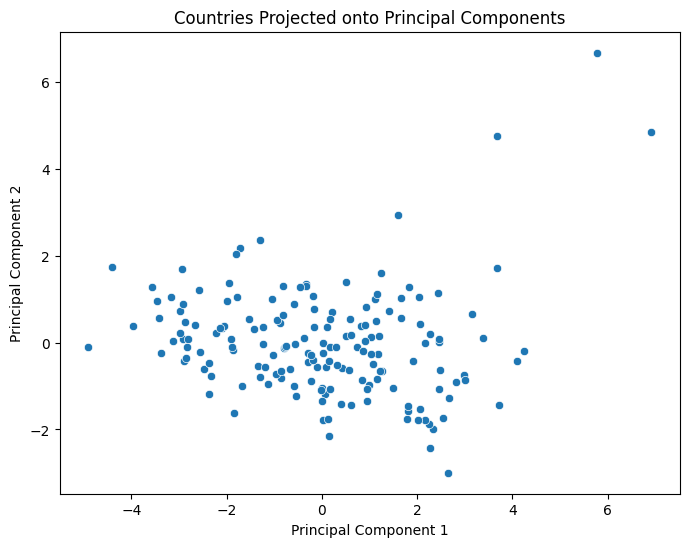

In [20]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"]
)

plt.title("Countries Projected onto Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## K-Means Clustering

K-Means is a centroid-based clustering algorithm that groups similar observations together.

Before fitting the model, the optimal number of clusters will be estimated using the Elbow Method and Silhouette Score.

In [21]:
# Elbow Method

inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)

    inertia.append(kmeans.inertia_)

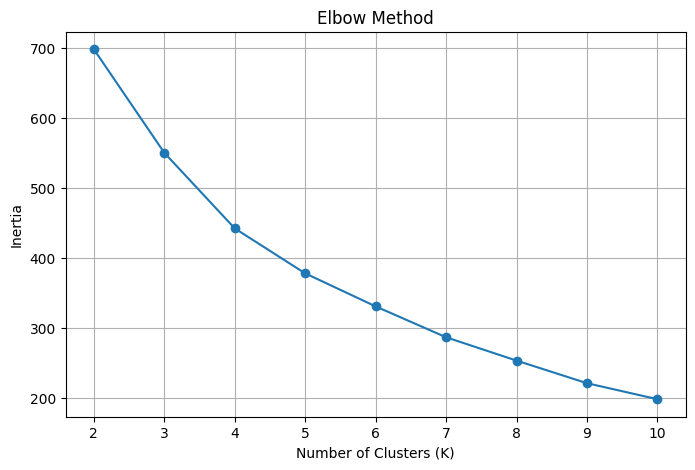

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [23]:
# Silhouette Scores

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(
        X_pca,
        labels
    )

    silhouette_scores.append(score)

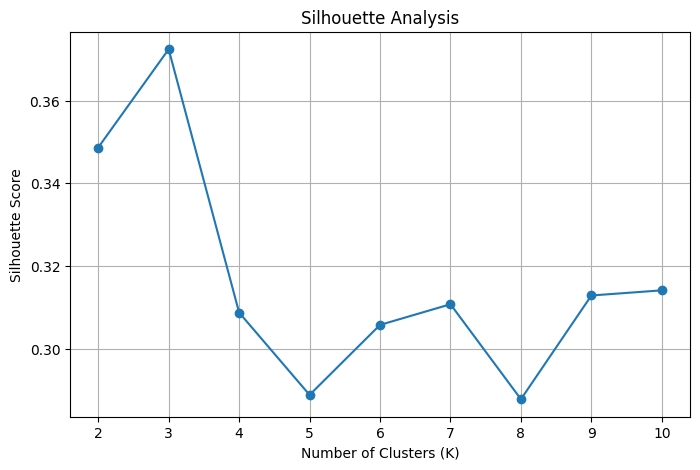

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

### Selecting the Number of Clusters

Based on the Elbow Curve and Silhouette Analysis, K = 3 was selected as it provides a good balance between cluster separation and interpretability.

In [25]:
# Final KMeans Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca)

pca_df["KMeans_Cluster"] = kmeans_labels

print("K-Means clustering completed.")

K-Means clustering completed.


In [26]:
# Silhouette Score

kmeans_silhouette = silhouette_score(
    X_pca,
    kmeans_labels
)

print(
    f"K-Means Silhouette Score: {kmeans_silhouette:.4f}"
)

K-Means Silhouette Score: 0.3724


In [27]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=["PC1","PC2","PC3"]
)

cluster_centers

,PC1,PC2,PC3
0,-1.901334,0.263055,0.053187
1,1.241625,-0.369269,-0.046362
2,5.460225,5.432473,0.211648


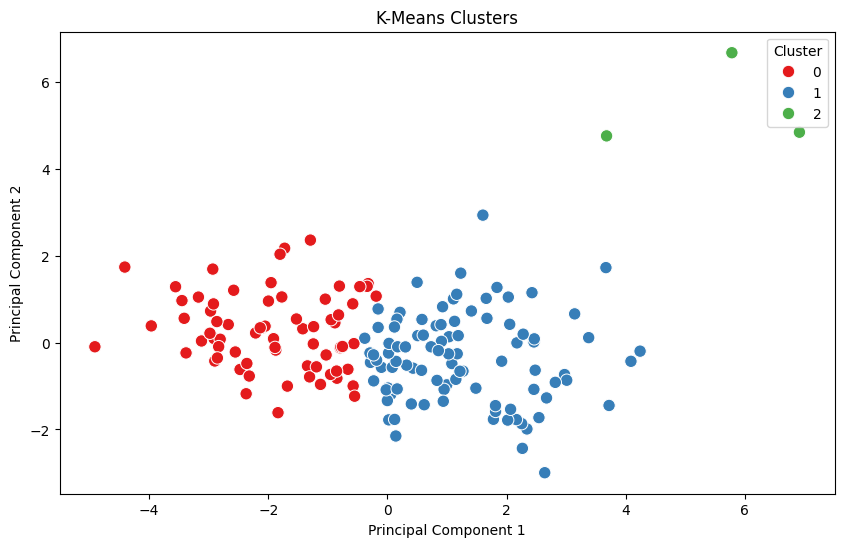

In [28]:
# Cluster Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="KMeans_Cluster",
    palette="Set1",
    s=80
)

plt.title("K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

In [29]:
# Add clusters back to original dataset

df["KMeans_Cluster"] = kmeans_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


## Cluster Interpretation

After grouping countries into clusters, it is important to understand the characteristics of each cluster.

Cluster profiling helps identify which groups represent developed, developing, or underdeveloped countries based on their socio-economic indicators.

In [30]:
# Cluster-wise averages

cluster_profile = df.groupby("KMeans_Cluster").mean(numeric_only=True)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,74.278571,30.512843,5.894857,42.785227,4521.900000,11.769214,62.280000,4.343143,2168.914286
1,12.544681,44.694681,7.502128,46.443617,25048.191489,4.982096,76.371277,1.959043,19579.680851
2,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667


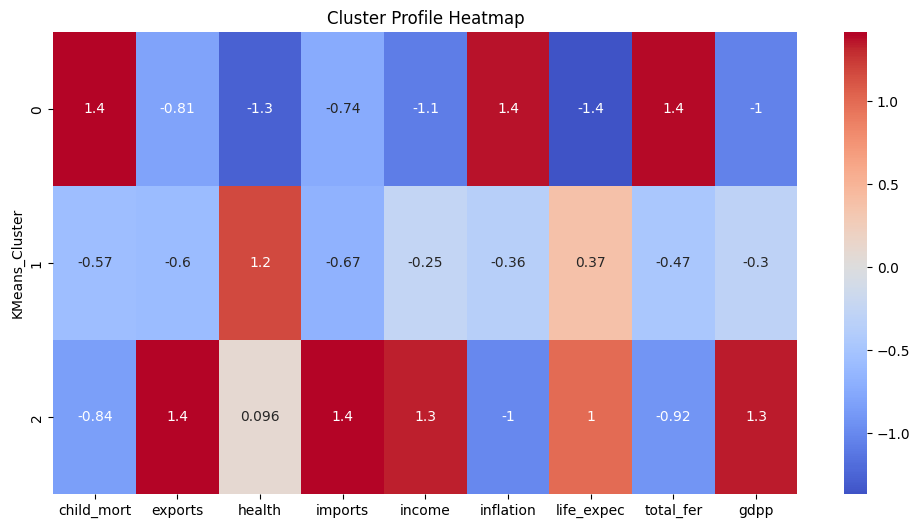

In [31]:
scaled_cluster_profile = scaler.fit_transform(cluster_profile)

scaled_cluster_profile = pd.DataFrame(
    scaled_cluster_profile,
    columns=cluster_profile.columns,
    index=cluster_profile.index
)

plt.figure(figsize=(12,6))

sns.heatmap(
    scaled_cluster_profile,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Cluster Profile Heatmap")

plt.show()

## Hierarchical Clustering

Hierarchical clustering builds clusters by repeatedly merging similar observations.

A dendrogram provides a visual representation of how clusters are formed and helps estimate an appropriate number of clusters.

In [32]:
# Generate linkage matrix

linked = linkage(
    X_pca,
    method="ward"
)

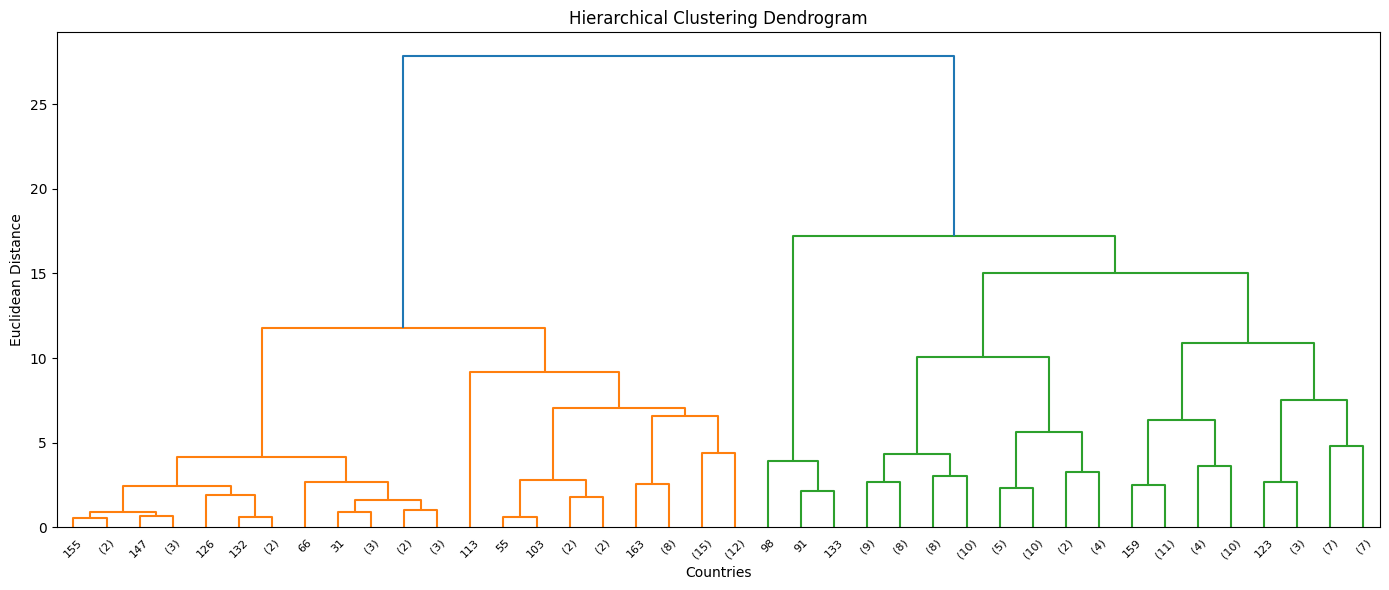

In [33]:
# Dendrogram

plt.figure(figsize=(14,6))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Countries")
plt.ylabel("Euclidean Distance")

plt.tight_layout()

plt.show()

## Agglomerative Clustering

Based on the dendrogram, Agglomerative Clustering is applied to divide the countries into groups.

For consistency, three clusters are selected.

In [34]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_pca)

print("Hierarchical clustering completed.")

Hierarchical clustering completed.


In [35]:
hierarchical_silhouette = silhouette_score(
    X_pca,
    hierarchical_labels
)

print(
    f"Hierarchical Silhouette Score: {hierarchical_silhouette:.4f}"
)

Hierarchical Silhouette Score: 0.3261


In [36]:
pca_df["Hierarchical_Cluster"] = hierarchical_labels

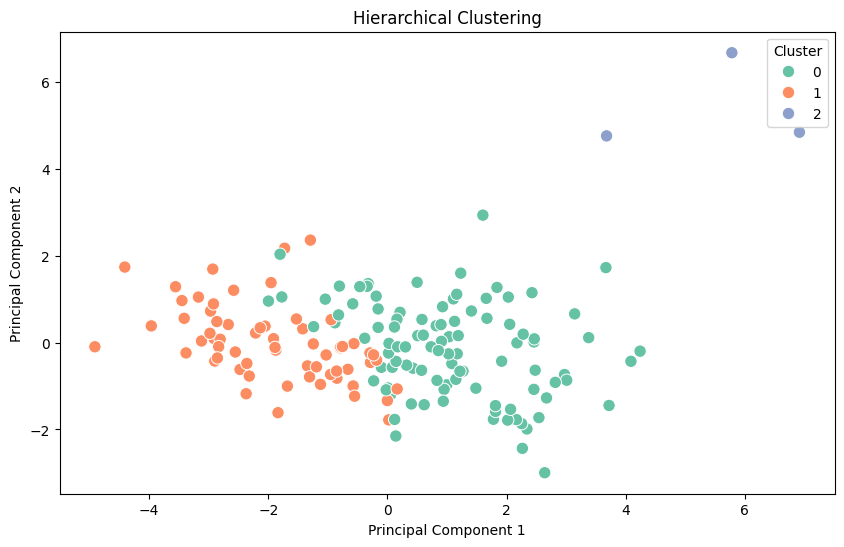

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Hierarchical_Cluster",
    palette="Set2",
    s=80
)

plt.title("Hierarchical Clustering")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

## Comparing Clustering Algorithms

The silhouette score is used to evaluate cluster quality.

Higher values generally indicate better cluster separation and cohesion.

In [38]:
comparison_df = pd.DataFrame({
    "Algorithm":[
        "K-Means",
        "Hierarchical"
    ],
    "Silhouette Score":[
        kmeans_silhouette,
        hierarchical_silhouette
    ]
})

comparison_df

,Algorithm,Silhouette Score
0,K-Means,0.372416
1,Hierarchical,0.326058


In [39]:
comparison_df.sort_values(
    by="Silhouette Score",
    ascending=False
)

,Algorithm,Silhouette Score
0,K-Means,0.372416
1,Hierarchical,0.326058


## Feature Importance Analysis

Although clustering does not use a target variable, a Random Forest model can be trained using the cluster labels generated by K-Means.

This helps identify which features contribute most to cluster separation.

In [40]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_scaled,
    kmeans_labels
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [41]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,child_mort,0.258376
6,life_expec,0.242664
7,total_fer,0.158434
4,income,0.111555
8,gdpp,0.092399
3,imports,0.040018
5,inflation,0.037423
1,exports,0.033752
2,health,0.025379


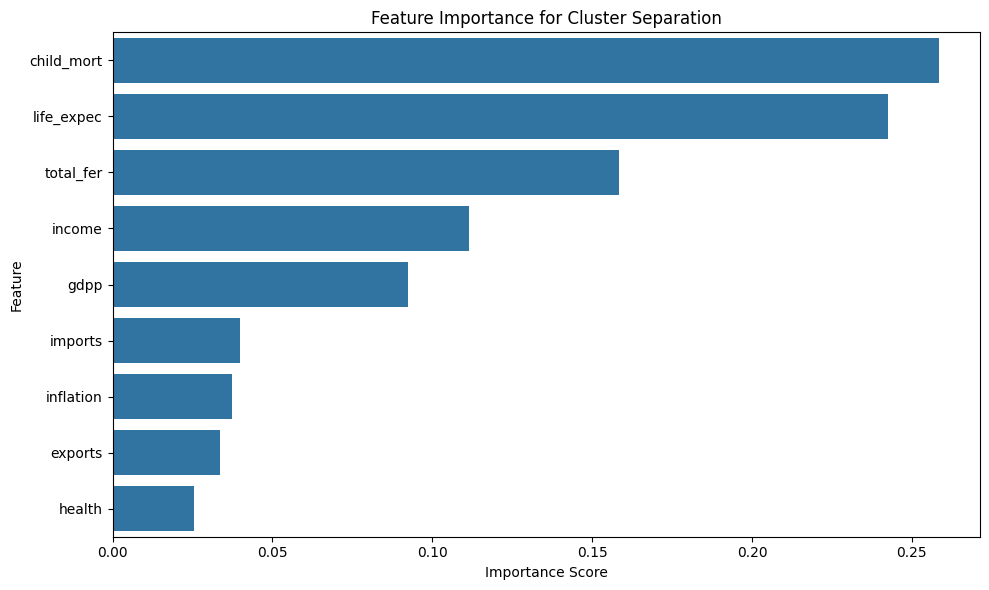

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance for Cluster Separation"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Observation

Income, GDP per capita, child mortality, and life expectancy appear among the most influential variables in separating countries into distinct clusters.

These features play a major role in distinguishing developed, developing, and underdeveloped nations.

## Identifying Countries Requiring Aid

The primary objective of this project is to identify countries that may require financial assistance.

Based on the cluster analysis, Cluster 0 represents countries with:

- High child mortality
- Low income
- Low GDP per capita
- Lower life expectancy

These countries are considered the most vulnerable and may benefit the most from humanitarian support.

In [43]:
# Countries belonging to the aid-priority cluster

aid_cluster = 0

aid_countries = df[
    df["KMeans_Cluster"] == aid_cluster
]

print(
    f"Number of countries in aid-priority cluster: {len(aid_countries)}"
)

aid_countries.head()

Number of countries in aid-priority cluster: 70


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,KMeans_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,0
12,Bangladesh,49.4,16.0,3.52,21.8,2440,7.140,70.4,2.33,758,0
17,Benin,111.0,23.8,4.10,37.2,1820,0.885,61.8,5.36,758,0
19,Bolivia,46.6,41.2,4.84,34.3,5410,8.780,71.6,3.20,1980,0


In [44]:
# Ranking vulnerable countries

priority_countries = aid_countries.sort_values(
    by=["gdpp", "income"],
    ascending=True
)

priority_countries[
    [
        "country",
        "income",
        "gdpp",
        "child_mort",
        "life_expec"
    ]
].head(20)

,country,income,gdpp,child_mort,life_expec
26,Burundi,764,231,93.6,57.7
88,Liberia,700,327,89.3,60.8
37,"Congo, Dem. Rep.",609,334,116.0,57.5
112,Niger,814,348,123.0,58.8
132,Sierra Leone,1220,399,160.0,55.0
93,Madagascar,1390,413,62.2,60.8
106,Mozambique,918,419,101.0,54.5
31,Central African Republic,888,446,149.0,47.5
94,Malawi,1030,459,90.5,53.1
50,Eritrea,1420,482,55.2,61.7


In [45]:
# Top 10 countries requiring aid

top_10_aid = priority_countries[
    [
        "country",
        "income",
        "gdpp",
        "child_mort",
        "life_expec"
    ]
].head(10)

top_10_aid

,country,income,gdpp,child_mort,life_expec
26,Burundi,764,231,93.6,57.7
88,Liberia,700,327,89.3,60.8
37,"Congo, Dem. Rep.",609,334,116.0,57.5
112,Niger,814,348,123.0,58.8
132,Sierra Leone,1220,399,160.0,55.0
93,Madagascar,1390,413,62.2,60.8
106,Mozambique,918,419,101.0,54.5
31,Central African Republic,888,446,149.0,47.5
94,Malawi,1030,459,90.5,53.1
50,Eritrea,1420,482,55.2,61.7


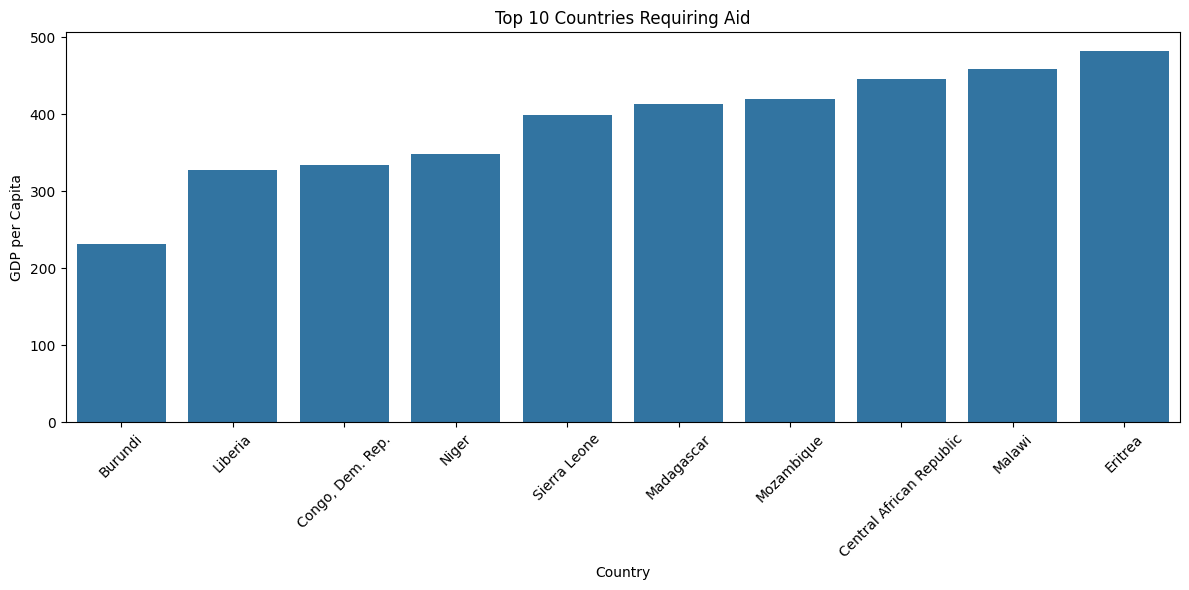

In [46]:
# Visualization of Top 10 Countries

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_aid,
    x="country",
    y="gdpp"
)

plt.title("Top 10 Countries Requiring Aid")
plt.xlabel("Country")
plt.ylabel("GDP per Capita")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Project Summary

This project analyzed socio-economic and health indicators of countries to identify meaningful patterns using unsupervised learning.

The dataset was cleaned, standardized, and reduced using PCA before applying clustering techniques. K-Means was used to segment countries into distinct groups, and cluster profiling helped interpret their characteristics.

The final analysis identified a low-income, high-child-mortality cluster as the most vulnerable group, which can help HELP International prioritize financial aid more effectively.

# Conclusion

The analysis successfully grouped countries into three distinct clusters representing developed, developing, and underdeveloped economies. Cluster 0 was identified as the most vulnerable group due to its low income, low GDP per capita, high child mortality, and lower life expectancy. These findings can assist HELP International in prioritizing aid allocation.